In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [11]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 7 .Clusstering DPMMs Algorithms

In [12]:
df = df.drop(columns='CustomerID')

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


In [14]:
dpmm = BayesianGaussianMixture(
    n_components=4,
    weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=0.1, 
    max_iter=500,
    random_state=42,
)
dpmm.fit(X_cleaned)
labels = dpmm.predict(X_cleaned)

Batas maksimal cluster yang disediakan : 10
Jumlah cluster yang otomatis ditemukan : 4


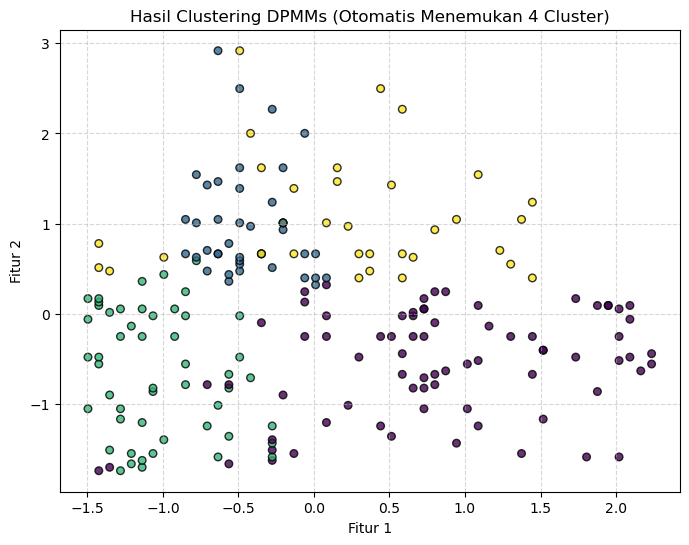

In [15]:
active_clusters = np.sum(dpmm.weights_ > 0.01)
print(f"Batas maksimal cluster yang disediakan : 10")
print(f"Jumlah cluster yang otomatis ditemukan : {active_clusters}")

# 5. VISUALISASI HASIL
plt.figure(figsize=(8, 6))
plt.scatter(
    X_cleaned.values[:, 0],X_cleaned.values[:, 1], c=labels, cmap="viridis", s=30, alpha=0.8, edgecolors="k"
)
plt.title(
    f"Hasil Clustering DPMMs (Otomatis Menemukan {active_clusters} Cluster)"
)
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()